# Loan Default Risk decision system

## Problem Statement:  
##### Banks and NBFCs face rising NPAs (Non‑Performing Assets) driven by irregular payments, borrower bankruptcies, poor creditworthiness, and financial distress.

## Goal:  
##### Leverage machine learning to identify hidden patterns among defaulters and estimate the probability of loan default using personal, financial, loan, and credit data.

## Solution Approach:  
##### Segment borrowers into risk tiers (low, medium, high) to enable proactive interventions, reduce NPAs, and safeguard revenue for BFSI institutions.

## Importing necessary libraries required for data science lifecycle

In [1]:
import pandas as pd
import pandera.pandas as pa
import warnings 
warnings.filterwarnings('ignore')
from pandera import Column, DataFrameSchema, Check
from pandera.errors import SchemaError
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.metrics import roc_curve, precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow

In [2]:
## Data and Model tracking using mlflow autolog method
mlflow.autolog()

2026/04/14 19:47:41 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/04/14 19:47:46 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/14 19:47:47 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/14 19:47:47 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


## Data Extraction from csv file

In [3]:
df = pd.read_csv('C:/Users/aksha/Credit_Risk_Decision_System/data/loan_dataset_20000.csv')

## Loading the data

In [4]:
# Ensuring that all the features will be visible from the table
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [6]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
len(num_cols), len(cat_cols)

(16, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

## Information around the data

##### So there are 22 features with 20000 numbers of borrowers. These features include 16 numerical features and 6 categorical features.

In [8]:
df.columns

Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')

## Data Annotation (Labeling the data column names to Pascalcase)

In [9]:
def annotate_data(data):
    annot_data = data.rename(columns={
        'age': 'Age',
        'gender': 'Gender',
        'marital_status': 'MaritalStatus',
        'education_level': 'EducationLevel', 
        'annual_income': 'AnnualIncome',
        'monthly_income': 'MonthlyIncome', 
        'employment_status': 'EmploymentStatus', 
        'debt_to_income_ratio': 'DebtToIncomeRatio',
        'credit_score': 'CreditScore', 
        'loan_amount': 'LoanAmount', 
        'loan_purpose': 'LoanPurpose', 
        'interest_rate': 'InterestRate',
        'loan_term': 'LoanTerm', 
        'installment': 'Installment', 
        'grade_subgrade': 'GradeSubgrade', 
        'num_of_open_accounts': 'NumOfOpenAccounts',
        'total_credit_limit': 'TotalCreditLimit', 
        'current_balance': 'CurrentBalance', 
        'delinquency_history': 'DelinquencyHistory',
        'public_records': 'PublicRecords', 
        'num_of_delinquencies': 'NumOfDelinquencies', 
        'loan_paid_back': 'LoanPaidBack'
    })
    return annot_data

df = annotate_data(df)

In [10]:
df.head()

,Age,Gender,MaritalStatus,EducationLevel,AnnualIncome,MonthlyIncome,EmploymentStatus,DebtToIncomeRatio,CreditScore,LoanAmount,LoanPurpose,InterestRate,LoanTerm,Installment,GradeSubgrade,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanPaidBack
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [11]:
"""The below code converts the loan paid back to loan default. Here we have reversed the expression 
because our focus is to identify defaulters as well as those who paid back the loans. So we labeled defaulters
as 1 (defaulters -> 1) and those who paid back as non-defaulters (non-defaulters -> 0)"""

'The below code converts the loan paid back to loan default. Here we have reversed the expression \nbecause our focus is to identify defaulters as well as those who paid back the loans. So we labeled defaulters\nas 1 (defaulters -> 1) and those who paid back as non-defaulters (non-defaulters -> 0)'

In [12]:
df['LoanDefault'] = 1 - df['LoanPaidBack']
new_df = df.drop(columns=['LoanPaidBack'])

In [13]:
new_df.head()

,Age,Gender,MaritalStatus,EducationLevel,AnnualIncome,MonthlyIncome,EmploymentStatus,DebtToIncomeRatio,CreditScore,LoanAmount,LoanPurpose,InterestRate,LoanTerm,Installment,GradeSubgrade,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanDefault
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,0
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,0
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,0
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,0
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,0


## Data Validation part

In [14]:
# Data and Schema Validation using Pandera 
def valid_data(df):
    df['LoanID'] = 10000000 + df.index
    new_df = df[['LoanID', 'Age', 'Gender', 'MaritalStatus', 'EducationLevel', 'AnnualIncome',
                 'MonthlyIncome', 'EmploymentStatus', 'DebtToIncomeRatio','CreditScore', 
                 'LoanAmount', 'LoanPurpose', 'InterestRate','LoanTerm', 'Installment', 
                 'NumOfOpenAccounts','TotalCreditLimit', 'CurrentBalance', 'DelinquencyHistory',
                 'PublicRecords', 'NumOfDelinquencies', 'GradeSubgrade', 'LoanDefault']]

    cat_cols = new_df.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        new_df[col] = new_df[col].str.capitalize()

    schema = DataFrameSchema({
        'Age' : Column(int, checks=Check.in_range(18, 100), nullable=False),
        'Gender' : Column(str, checks=Check.isin(['Male', 'Female', 'Other']), nullable=False),
        'MaritalStatus': Column(str, checks=Check.isin(['Single', 'Married', 'Widowed', 'Divorced']), nullable=False),
        'EducationLevel': Column(str, checks=Check.isin(["Bachelor's", 'High school', "Master's", 'Other', 'Phd']), nullable=False),
        'AnnualIncome' : Column(float, checks=Check.ge(0.0), nullable=False),
        'MonthlyIncome' : Column(float, checks=Check.ge(0.0), nullable=False),
        'EmploymentStatus': Column(str, checks=Check.isin(["Employed", 'Self-employed', "Unemployed", 'Retired', 'Student']), nullable=False),
        'DebtToIncomeRatio': Column(float, checks=Check.in_range(0.0, 1.0), nullable=False),
        'LoanAmount': Column(float, checks=Check.ge(0.0), nullable=False),  
        'CreditScore': Column(int, checks=Check.in_range(300, 850), nullable=False),
        'LoanPurpose': Column(str, checks=Check.isin(['Debt consolidation', 'Other', 'Car', 'Home', 
                                                      'Education', 'Business', 'Medical', 'Vacation']), nullable=False),
        'InterestRate': Column(float, checks=Check.in_range(0.0, 25.0), nullable=False),
        'LoanTerm': Column(int, checks= Check.in_range(12, 60), nullable=False),
        'Installment': Column(float, checks=Check.ge(0.0), nullable=False),
        'NumOfOpenAccounts': Column(int, nullable=False),
        'TotalCreditLimit': Column(float, checks=Check.ge(0.0), nullable=False),
        'CurrentBalance': Column(float, checks=Check.ge(0.0), nullable=False),
        'DelinquencyHistory': Column(int, nullable=False),
        'PublicRecords': Column(int, nullable=False), 
        'NumOfDelinquencies': Column(int, nullable=False),
        'GradeSubgrade': Column(str, nullable=False),
        'LoanDefault': Column(int, checks=Check.isin([0, 1]), nullable=False)}, 
        checks=[
        # Row-wise check: no NaN in any row
        Check(lambda df: df.isna().sum().sum() == 0, element_wise=False),

        # DataFrame-level check: no duplicate rows
        Check(lambda df: df.duplicated().sum().sum() == 0, element_wise=False),
        
        # Total credit limit should always be higher than or equal to current outstanding balance
        Check(lambda df: df['TotalCreditLimit'] >= df['CurrentBalance'], element_wise=False)
    ])

    return schema.validate(new_df)

In [15]:
valid_df = valid_data(new_df)

In [16]:
## Data Validated successfully.

In [17]:
## head (top 5) data
valid_df.head()

,LoanID,Age,Gender,MaritalStatus,EducationLevel,AnnualIncome,MonthlyIncome,EmploymentStatus,DebtToIncomeRatio,CreditScore,LoanAmount,LoanPurpose,InterestRate,LoanTerm,Installment,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,GradeSubgrade,LoanDefault
0,10000000,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,7,40833.47,24302.07,1,0,1,B5,0
1,10000001,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,5,27968.01,10803.01,1,0,3,F1,0
2,10000002,49,Female,Single,High school,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,2,15502.25,4505.44,0,0,0,B4,0
3,10000003,35,Female,Single,High school,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,7,18157.79,5525.63,4,0,5,A5,0
4,10000004,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,1,17467.56,3593.91,2,0,2,D5,0


In [18]:
## tail (bottom 5) data
valid_df.tail()

,LoanID,Age,Gender,MaritalStatus,EducationLevel,AnnualIncome,MonthlyIncome,EmploymentStatus,DebtToIncomeRatio,CreditScore,LoanAmount,LoanPurpose,InterestRate,LoanTerm,Installment,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,GradeSubgrade,LoanDefault
19995,10019995,39,Female,Married,Bachelor's,39640.08,3303.34,Employed,0.275,691,16322.23,Debt consolidation,15.05,36,566.22,2,23748.10,5801.45,1,0,4,C5,1
19996,10019996,66,Female,Married,Bachelor's,32062.90,2671.91,Employed,0.367,758,16697.34,Debt consolidation,11.89,36,553.71,8,49929.65,40901.31,3,0,3,B5,0
19997,10019997,65,Female,Single,Master's,18642.02,1553.50,Student,0.106,751,23924.78,Debt consolidation,10.06,36,772.66,3,13137.57,5075.67,1,0,2,B4,0
19998,10019998,35,Male,Married,Master's,22181.39,1848.45,Retired,0.275,646,16920.13,Other,16.06,36,595.36,5,19580.82,3876.16,4,0,5,D2,0
19999,10019999,36,Female,Married,Other,23737.70,1978.14,Employed,0.228,630,15769.75,Business,13.07,36,531.88,8,43013.59,12753.03,2,0,2,D2,1


## Outlier detection using IQR (Intermediate Quantile Range) method

In [19]:
## Outliers detection using IQR method
outliers_data = []
for col in valid_df.select_dtypes(include='number').columns:
    if col == 'LoanDefault':
        break
    Q1 = valid_df[col].quantile(0.75)
    Q3 = valid_df[col].quantile(0.25)
    IQR = Q1 - Q3
    lower_bound = Q3 - IQR*1.5
    upper_bound = Q1 + IQR*1.5
    outliers = ((valid_df[col] < lower_bound) | (valid_df[col] > upper_bound)).astype(int)
    print(f"Outliers for {col}: {outliers.sum()}")
    outliers_data.append({
        'Feature': col,
        'Outliers': outliers.sum()
    })

Outliers for LoanID: 0
Outliers for Age: 0
Outliers for AnnualIncome: 924
Outliers for MonthlyIncome: 924
Outliers for DebtToIncomeRatio: 262
Outliers for CreditScore: 74
Outliers for LoanAmount: 76
Outliers for InterestRate: 141
Outliers for LoanTerm: 0
Outliers for Installment: 150
Outliers for NumOfOpenAccounts: 283
Outliers for TotalCreditLimit: 950
Outliers for CurrentBalance: 1015
Outliers for DelinquencyHistory: 142
Outliers for PublicRecords: 1003
Outliers for NumOfDelinquencies: 364


## Creating Binary Dummy indicators for categorical features

In [20]:
valid_dummy_df = pd.get_dummies(df, drop_first=True, dtype='int')
valid_dummy_df.head()

,Age,AnnualIncome,MonthlyIncome,DebtToIncomeRatio,CreditScore,LoanAmount,InterestRate,LoanTerm,Installment,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanPaidBack,LoanDefault,Gender_Male,Gender_Other,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,EducationLevel_High School,EducationLevel_Master's,EducationLevel_Other,EducationLevel_PhD,EmploymentStatus_Retired,EmploymentStatus_Self-employed,EmploymentStatus_Student,EmploymentStatus_Unemployed,LoanPurpose_Car,LoanPurpose_Debt consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Medical,LoanPurpose_Other,LoanPurpose_Vacation,GradeSubgrade_A2,GradeSubgrade_A3,GradeSubgrade_A4,GradeSubgrade_A5,GradeSubgrade_B1,GradeSubgrade_B2,GradeSubgrade_B3,GradeSubgrade_B4,GradeSubgrade_B5,GradeSubgrade_C1,GradeSubgrade_C2,GradeSubgrade_C3,GradeSubgrade_C4,GradeSubgrade_C5,GradeSubgrade_D1,GradeSubgrade_D2,GradeSubgrade_D3,GradeSubgrade_D4,GradeSubgrade_D5,GradeSubgrade_E1,GradeSubgrade_E2,GradeSubgrade_E3,GradeSubgrade_E4,GradeSubgrade_E5,GradeSubgrade_F1,GradeSubgrade_F2,GradeSubgrade_F3,GradeSubgrade_F4,GradeSubgrade_F5
0,59,24240.19,2020.02,0.074,743,17173.72,13.39,36,581.88,7,40833.47,24302.07,1,0,1,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,72,20172.98,1681.08,0.219,531,22663.89,17.81,60,573.17,5,27968.01,10803.01,1,0,3,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,49,26181.80,2181.82,0.234,779,3631.36,9.53,60,76.32,2,15502.25,4505.44,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,35,11873.84,989.49,0.264,809,14939.23,7.99,36,468.07,7,18157.79,5525.63,4,0,5,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,63,25326.44,2110.54,0.260,663,16551.71,15.20,60,395.50,1,17467.56,3593.91,2,0,2,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


## Anomaly detection using Isolation Forest

In [21]:
## ANOMALY detection using Isolation Forest
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.2, n_estimators=100, random_state=42)
iso.fit(valid_dummy_df)

2026/04/14 19:47:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/04/14 19:47:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/04/14 19:47:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/04/14 19:47:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/04/14 19:47:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/04/14 19:47:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/04/14 19:47:50 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/14 19:47:50 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/04/14 19:47:51 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The experiment 0 must be in the 'active' state. Current state is deleted.


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.2
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [22]:
valid_dummy_df['Anomaly'] = iso.predict(valid_dummy_df)

In [23]:
valid_dummy_df.head()

,Age,AnnualIncome,MonthlyIncome,DebtToIncomeRatio,CreditScore,LoanAmount,InterestRate,LoanTerm,Installment,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanPaidBack,LoanDefault,Gender_Male,Gender_Other,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,EducationLevel_High School,EducationLevel_Master's,EducationLevel_Other,EducationLevel_PhD,EmploymentStatus_Retired,EmploymentStatus_Self-employed,EmploymentStatus_Student,EmploymentStatus_Unemployed,LoanPurpose_Car,LoanPurpose_Debt consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Medical,LoanPurpose_Other,LoanPurpose_Vacation,GradeSubgrade_A2,GradeSubgrade_A3,GradeSubgrade_A4,GradeSubgrade_A5,GradeSubgrade_B1,GradeSubgrade_B2,GradeSubgrade_B3,GradeSubgrade_B4,GradeSubgrade_B5,GradeSubgrade_C1,GradeSubgrade_C2,GradeSubgrade_C3,GradeSubgrade_C4,GradeSubgrade_C5,GradeSubgrade_D1,GradeSubgrade_D2,GradeSubgrade_D3,GradeSubgrade_D4,GradeSubgrade_D5,GradeSubgrade_E1,GradeSubgrade_E2,GradeSubgrade_E3,GradeSubgrade_E4,GradeSubgrade_E5,GradeSubgrade_F1,GradeSubgrade_F2,GradeSubgrade_F3,GradeSubgrade_F4,GradeSubgrade_F5,Anomaly
0,59,24240.19,2020.02,0.074,743,17173.72,13.39,36,581.88,7,40833.47,24302.07,1,0,1,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,72,20172.98,1681.08,0.219,531,22663.89,17.81,60,573.17,5,27968.01,10803.01,1,0,3,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,49,26181.80,2181.82,0.234,779,3631.36,9.53,60,76.32,2,15502.25,4505.44,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,35,11873.84,989.49,0.264,809,14939.23,7.99,36,468.07,7,18157.79,5525.63,4,0,5,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,63,25326.44,2110.54,0.260,663,16551.71,15.20,60,395.50,1,17467.56,3593.91,2,0,2,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-1


In [24]:
valid_dummy_df['Anomaly'].value_counts()

Anomaly
 1    16000
-1     4000
Name: count, dtype: int64

In [25]:
## Out of 20000 cases, 16000 are non-anomalied and 4000 cases are anomalies

In [26]:
valid_df.LoanDefault.value_counts()

LoanDefault
0    15998
1     4002
Name: count, dtype: int64

In [27]:
## Out of 20000 borrowers, 15998 have paid back their loan where 4002 borrowers have defaulted on the loan

## Features Correlation Analysis

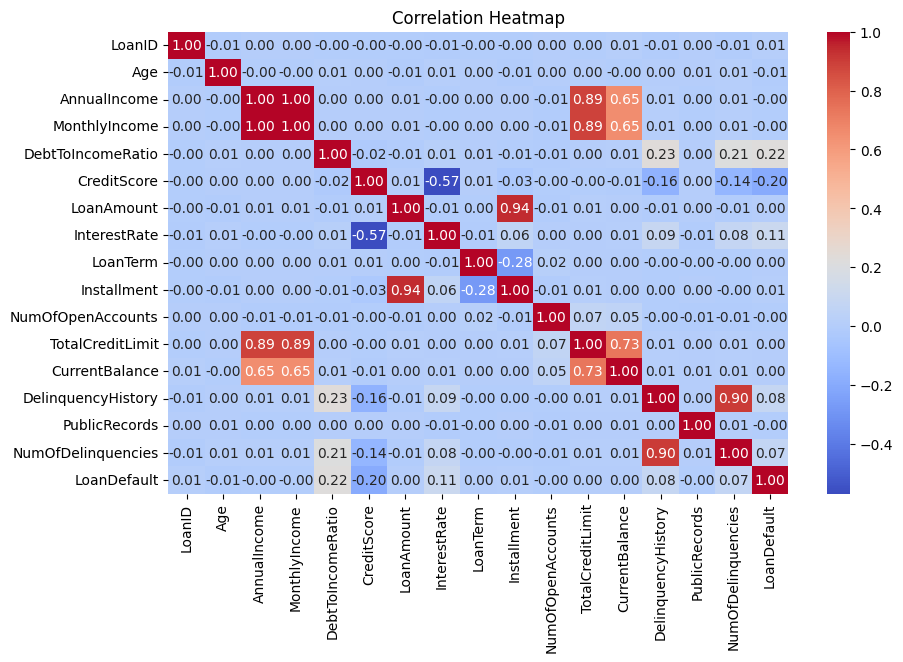

In [28]:
# correlation heatmap before feature engineering
num_cols = valid_df.select_dtypes(include='number').columns.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(valid_df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Exploratory Data Analysis (EDA)

In [29]:
outliers_df = pd.DataFrame(outliers_data).sort_values(by='Outliers', ascending=False)

<Axes: xlabel='Feature'>

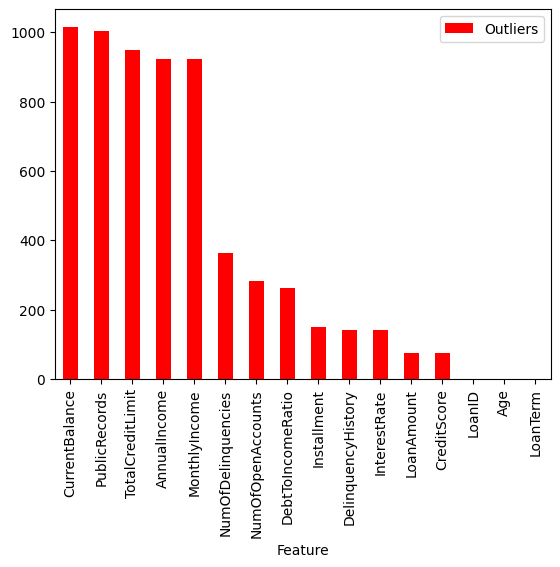

In [30]:
outliers_df.plot(kind='bar', color='red', x='Feature')

In [31]:
## More than 800 outliers are detected in Current Balance, Public Records, Total Credit Limit, Annual & Monthly Income

In [32]:
# Average Loan Default rate (%)
valid_dummy_df['LoanDefault'].mean()*100

20.01

In [33]:
# Average number of non_anomalies (%)
valid_dummy_df['Anomaly'].mean()*100

60.0

<Axes: xlabel='LoanDefault'>

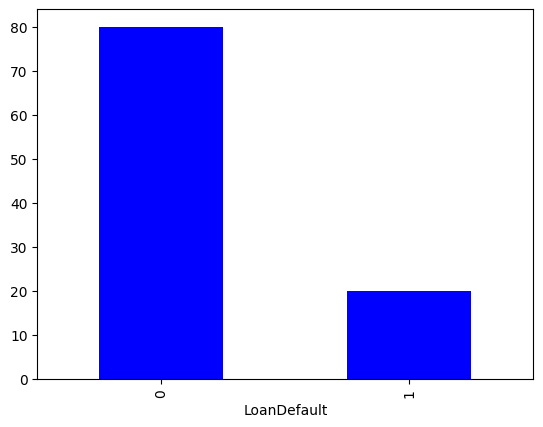

In [34]:
(valid_dummy_df['LoanDefault'].value_counts(normalize=True)*100).plot(kind='bar', color='blue')

<Axes: xlabel='Anomaly'>

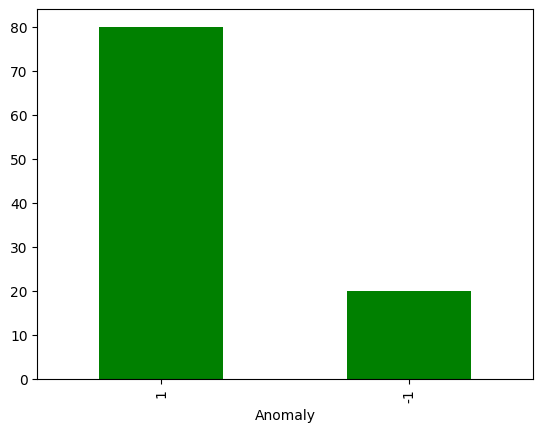

In [35]:
(valid_dummy_df['Anomaly'].value_counts(normalize=True)*100).plot(kind='bar', color='green')

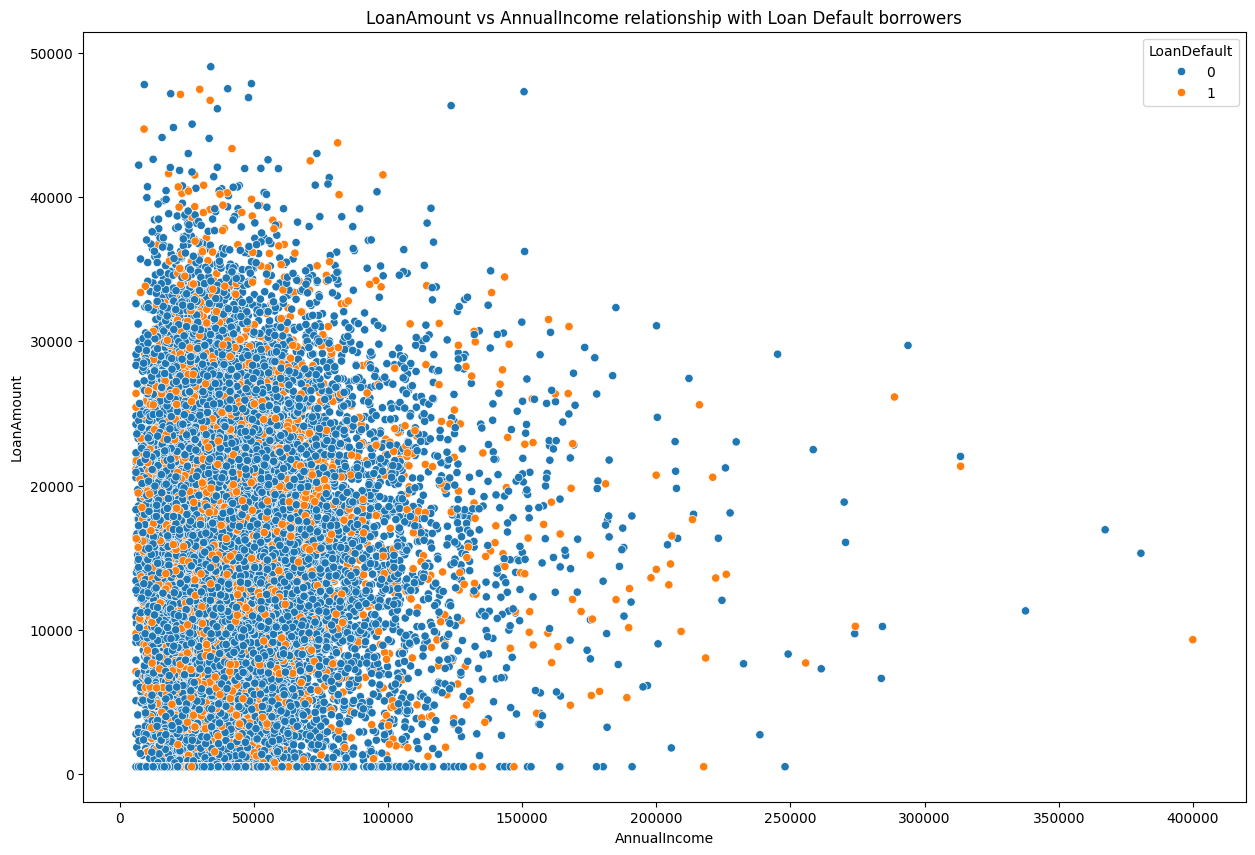

In [36]:
plt.figure(figsize=(15, 10))
sns.scatterplot(valid_dummy_df, x='AnnualIncome', y='LoanAmount', hue='LoanDefault')
plt.title('LoanAmount vs AnnualIncome relationship with Loan Default borrowers')
plt.show()

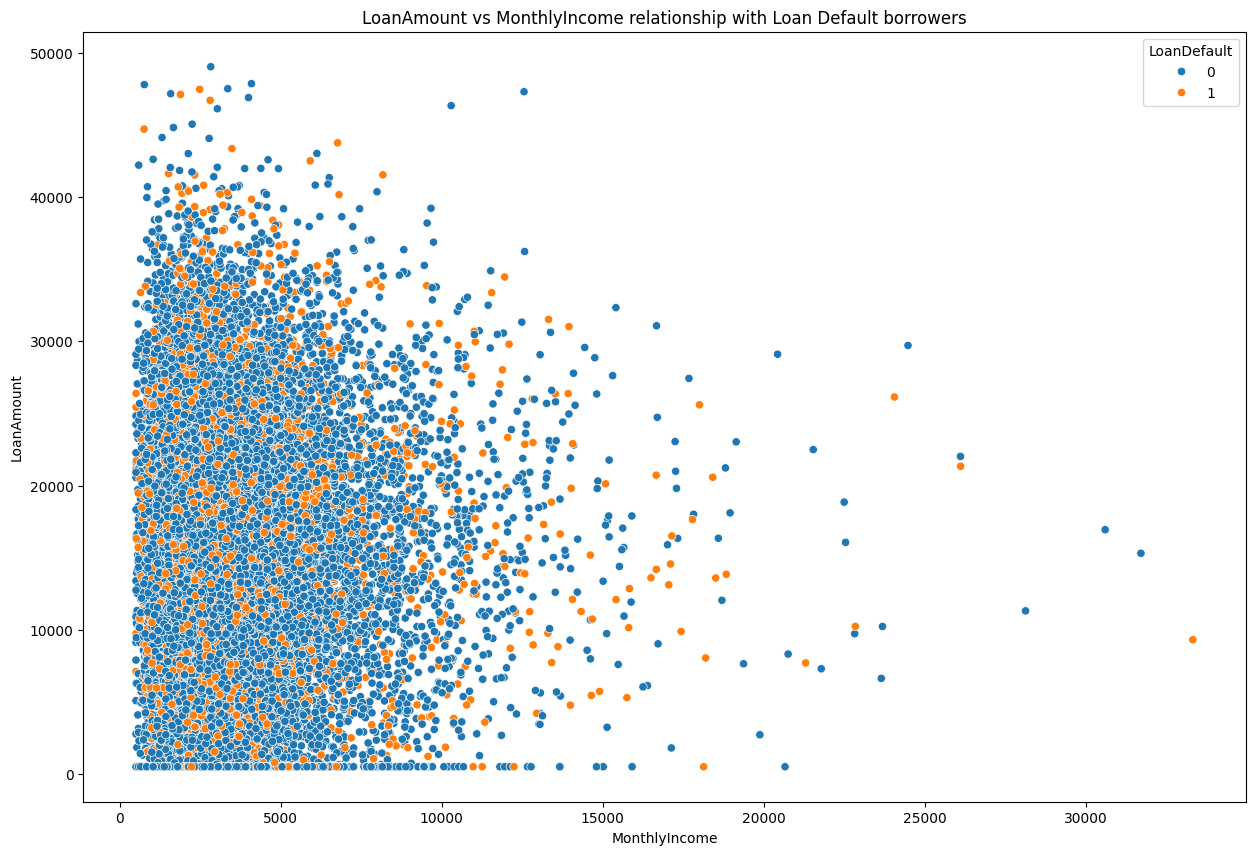

In [37]:
plt.figure(figsize=(15, 10))
sns.scatterplot(valid_dummy_df, x='MonthlyIncome', y='LoanAmount', hue='LoanDefault')
plt.title('LoanAmount vs MonthlyIncome relationship with Loan Default borrowers')
plt.show()

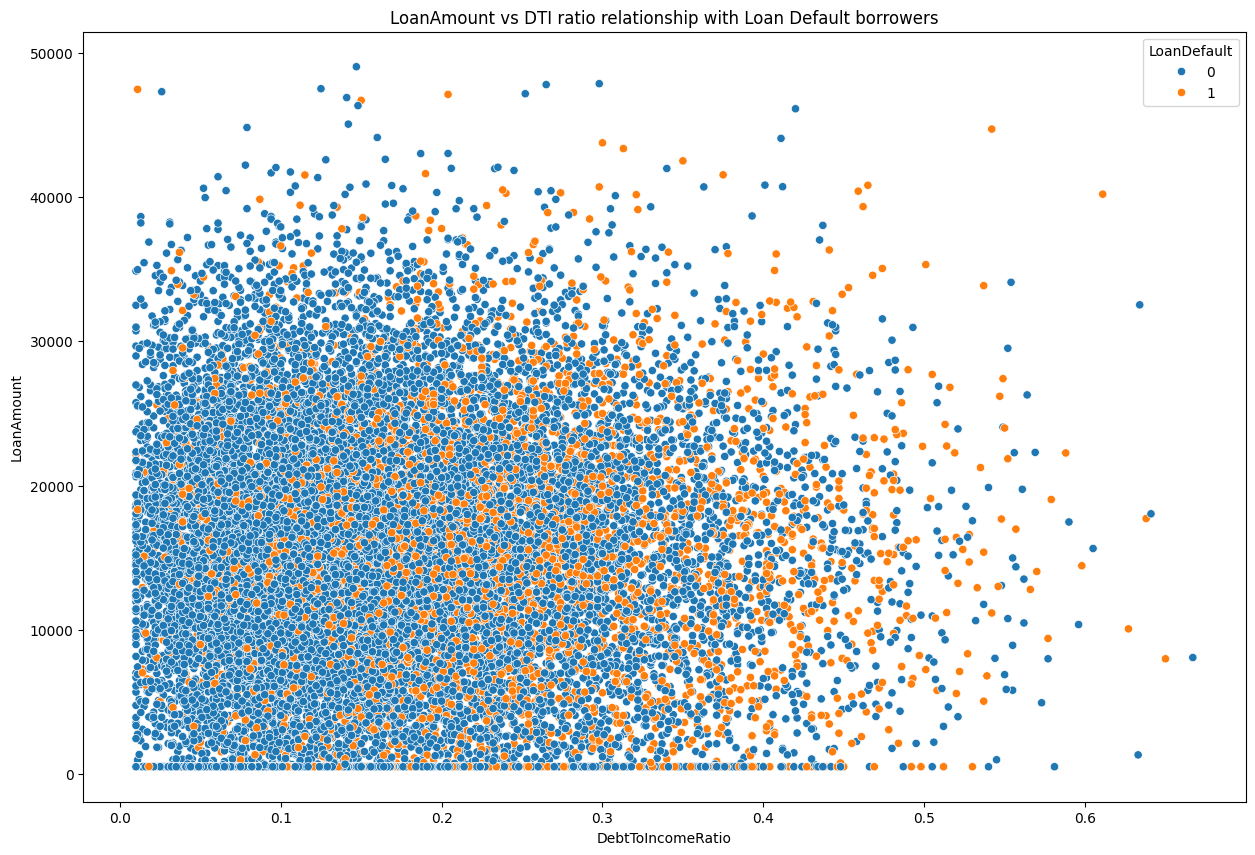

In [38]:
plt.figure(figsize=(15, 10))
sns.scatterplot(valid_dummy_df, x='DebtToIncomeRatio', y='LoanAmount', hue='LoanDefault')
plt.title('LoanAmount vs DTI ratio relationship with Loan Default borrowers')
plt.show()

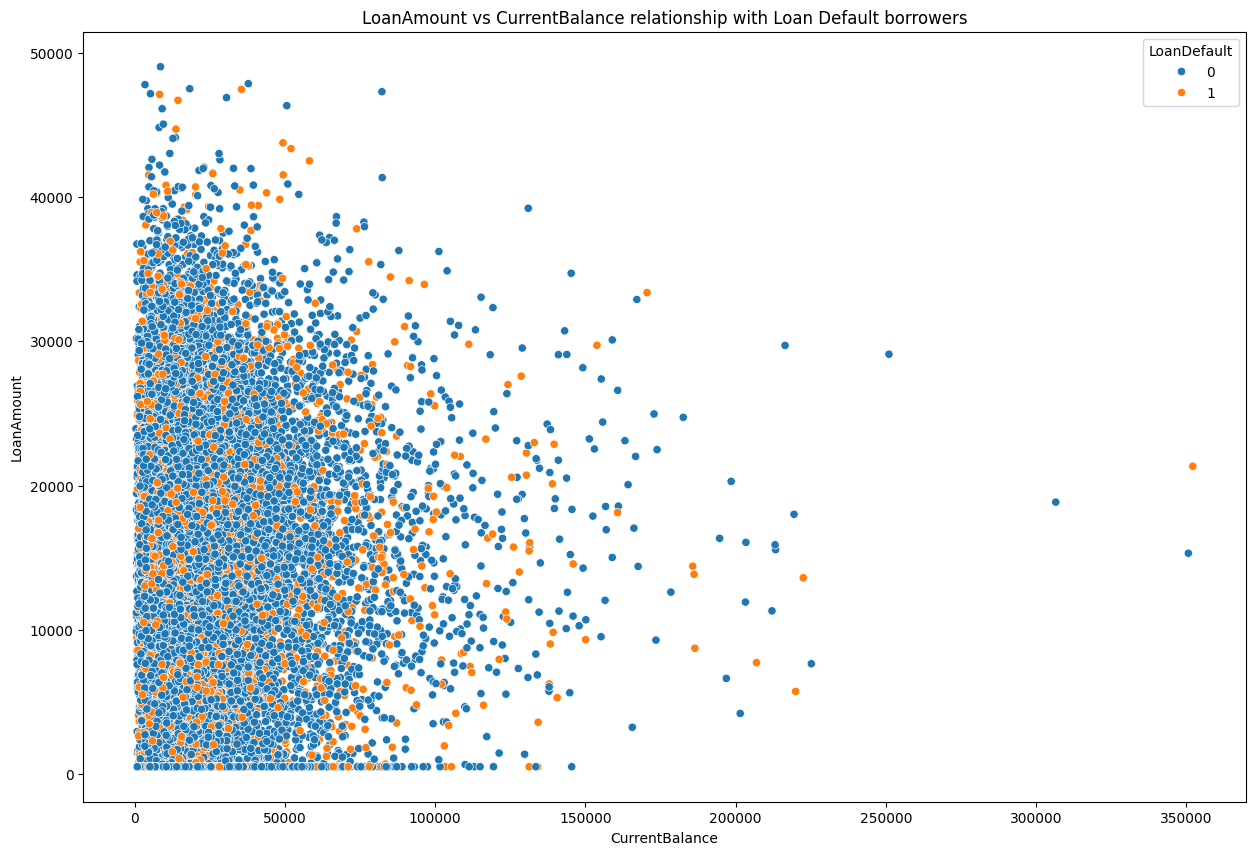

In [39]:
plt.figure(figsize=(15, 10))
sns.scatterplot(valid_dummy_df, x='CurrentBalance', y='LoanAmount', hue='LoanDefault')
plt.title('LoanAmount vs CurrentBalance relationship with Loan Default borrowers')
plt.show()

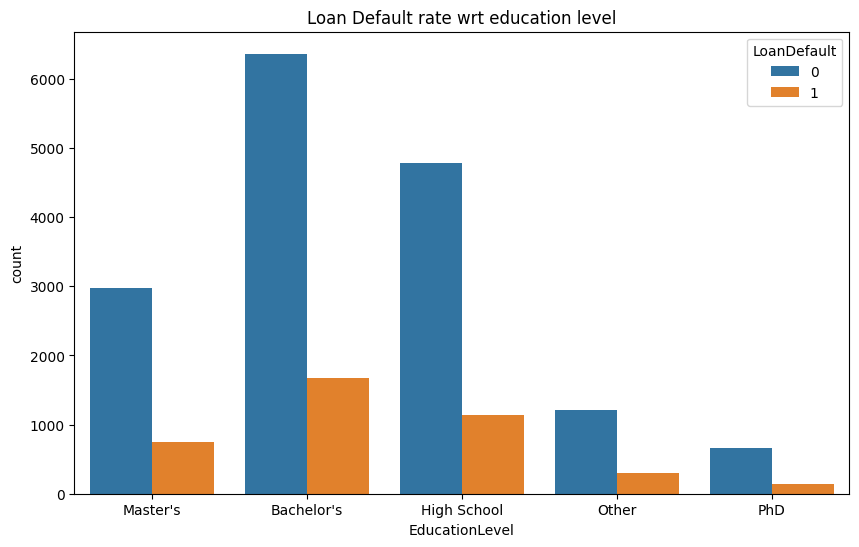

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(new_df, x='EducationLevel', hue='LoanDefault')
plt.title('Loan Default rate wrt education level')
plt.show()

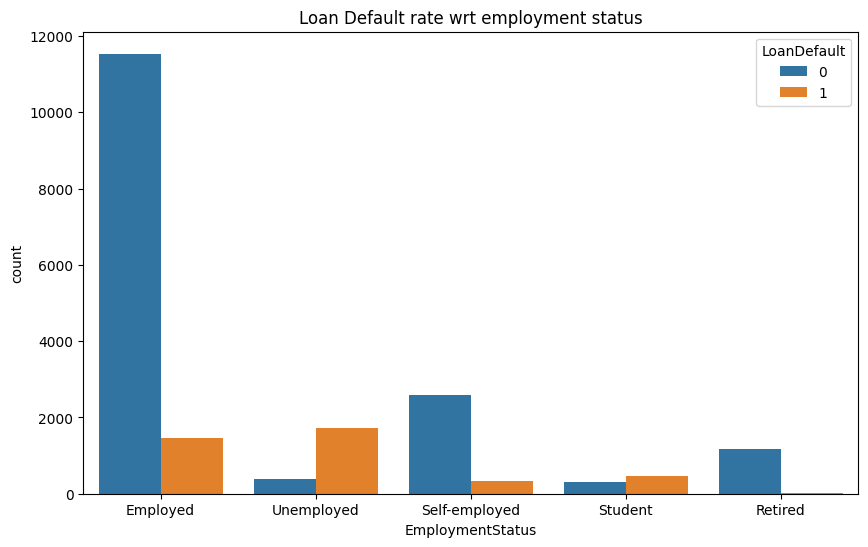

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(new_df, x='EmploymentStatus', hue='LoanDefault')
plt.title('Loan Default rate wrt employment status')
plt.show()

## Data Analysis using SQL

In [42]:
import pandasql as sql

query = 'Select Age, AnnualIncome from valid_dummy_df where age < 40'

result = sql.sqldf(query, locals())

In [43]:
result.shape

(6919, 2)

In [44]:
query1 = 'Select Age, AnnualIncome, LoanAmount \
          from valid_dummy_df where \
          LoanAmount <= AnnualIncome and LoanDefault = 1'
result = sql.sqldf(query1, locals())
print(result.head(), result.shape)

   Age  AnnualIncome  LoanAmount
0   41      24642.88     5905.27
1   43      53439.89    14712.38
2   60      27877.04    15819.70
3   22      40245.27     9831.78
4   45      27944.46     6268.32 (3553, 3)


In [45]:
query2 = 'Select Age, AnnualIncome, LoanAmount \
          from valid_dummy_df where \
          LoanAmount > AnnualIncome and LoanDefault = 1'
result = sql.sqldf(query2, locals())
print(result.head()) 
print(result.shape)

   Age  AnnualIncome  LoanAmount
0   23       6018.90    26387.55
1   37      23126.73    40266.07
2   48      12802.65    17686.21
3   59      13759.26    28644.58
4   59      12641.22    13940.90
(449, 3)


  EmploymentStatus  MaxIncome    AvgLoanAmt
0         Employed  367316.11  15068.407566
1          Retired  200361.60  15125.132866
2    Self-employed  380653.94  15218.411598
3          Student  400000.00  15670.936146
4       Unemployed  288767.91  15182.994075
(5, 3)


<Axes: xlabel='EmploymentStatus', ylabel='MaxIncome'>

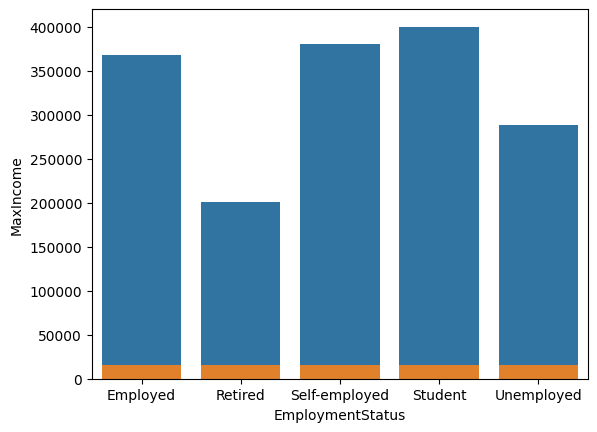

In [46]:
query3 = 'Select EmploymentStatus, MAX(AnnualIncome) as MaxIncome, AVG(LoanAmount) as AvgLoanAmt \
          from new_df group by EmploymentStatus'
result = sql.sqldf(query3, locals())
print(result) 
print(result.shape)
sns.barplot(result, x='EmploymentStatus', y='MaxIncome')
sns.barplot(result, x='EmploymentStatus', y='AvgLoanAmt')

  EmploymentStatus  LoanDefault  DefaultCount
0         Employed            0         11537
1         Employed            1          1470
2          Retired            0          1170
3          Retired            1             6
4    Self-employed            0          2589
5    Self-employed            1           334
6          Student            0           318
7          Student            1           463
8       Unemployed            0           384
9       Unemployed            1          1729
(10, 3)


<Axes: xlabel='EmploymentStatus', ylabel='DefaultCount'>

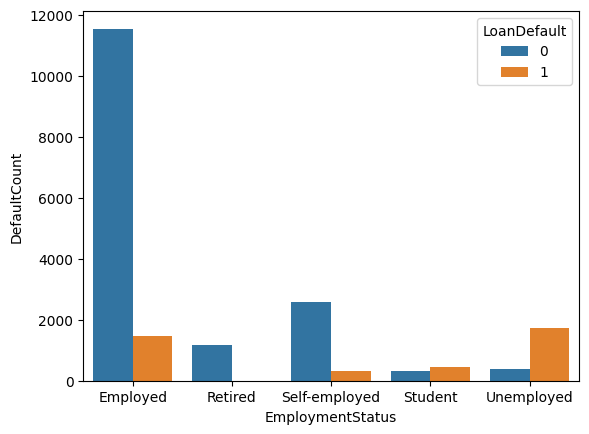

In [47]:
query4 = 'Select EmploymentStatus, LoanDefault, COUNT(LoanDefault) as DefaultCount \
          from new_df group by EmploymentStatus, LoanDefault'
result = sql.sqldf(query4, locals())
print(result) 
print(result.shape)
sns.barplot(result, x='EmploymentStatus', y='DefaultCount', hue='LoanDefault')

In [48]:
query5 = 'Select EducationLevel, LoanDefault, COUNT(LoanDefault) as DefaultCount \
          from new_df group by EducationLevel, LoanDefault'
result = sql.sqldf(query5, locals())
print(result) 
print(result.shape)

  EducationLevel  LoanDefault  DefaultCount
0     Bachelor's            0          6366
1     Bachelor's            1          1679
2    High School            0          4783
3    High School            1          1136
4       Master's            0          2971
5       Master's            1           753
6          Other            0          1212
7          Other            1           296
8            PhD            0           666
9            PhD            1           138
(10, 3)


  EducationLevel  LoanDefault  DefaultCount
0     Bachelor's            1          1679
1    High School            1          1136
2       Master's            1           753
3          Other            1           296
4            PhD            1           138
(5, 3)


<Axes: xlabel='EducationLevel'>

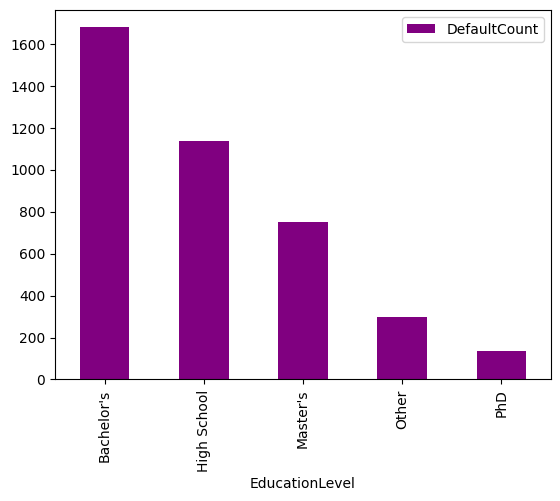

In [49]:
query6 = 'Select EducationLevel, LoanDefault, COUNT(LoanDefault) as DefaultCount \
          from new_df group by EducationLevel, LoanDefault \
          having LoanDefault = 1'
result = sql.sqldf(query6, locals())
print(result) 
print(result.shape)
result.plot(kind='bar', x='EducationLevel', y='DefaultCount', color='purple')

In [50]:
new_df['Anomaly'] = valid_dummy_df['Anomaly']

In [51]:
new_df.head()

,Age,Gender,MaritalStatus,EducationLevel,AnnualIncome,MonthlyIncome,EmploymentStatus,DebtToIncomeRatio,CreditScore,LoanAmount,LoanPurpose,InterestRate,LoanTerm,Installment,GradeSubgrade,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanDefault,LoanID,Anomaly
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,0,10000000,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,0,10000001,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,0,10000002,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,0,10000003,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,0,10000004,-1


## Feature Engineering

In [52]:
# Feature Engineering
new_df['LoanIncomeRatio'] = new_df['LoanAmount'] / new_df['AnnualIncome']
new_df['CreditRatio'] = new_df['CurrentBalance'] / new_df['TotalCreditLimit']
new_df['InstallmentIncomeRatio'] = new_df['Installment'] / new_df['MonthlyIncome']

## Train-test split

In [53]:
# train-test split
X = new_df.drop(columns=['AnnualIncome', 'LoanID', 'LoanDefault'])
y = new_df[['LoanDefault']]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16000, 24), (4000, 24), (16000, 1), (4000, 1))

## Features transformation using Standard Scaling, Robust and Min-max Scaling

In [54]:
# transformed features using StandardScaling, RobustScaling and MinMaxScaling
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

# StandardScaler
scaler_std = StandardScaler()

# RobustScaler
scaler_robust = RobustScaler()

# min-maxScaler
scaler_minmax = MinMaxScaler()

# One-hotEncoder
ohe = OneHotEncoder(handle_unknown='ignore')

num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

preprocessor_std = ColumnTransformer(transformers=[
    ('num', scaler_std, num_cols),
    ('cat', ohe, cat_cols)
], remainder='passthrough')

preprocessor_robust = ColumnTransformer(transformers=[
    ('num', scaler_robust, num_cols),
    ('cat', ohe, cat_cols)
], remainder='passthrough')

preprocessor_minmax = ColumnTransformer(transformers=[
    ('num', scaler_minmax, num_cols),
    ('cat', ohe, cat_cols)
], remainder='passthrough')

## Applying Scale position weight to handle data imbalance

In [55]:
scale_pos_weight = round(np.sum(y_train['LoanDefault'] == 0) / np.sum(y_train['LoanDefault'] == 1))
print(scale_pos_weight)

4


## Machine Learning model training and evaluation

In [56]:
from sklearn.pipeline import Pipeline
lgr = LogisticRegression(C=0.01, max_iter=1000, class_weight={0:1, 1:scale_pos_weight}, random_state=42)

lgr_std_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor_std),
    ('ml', lgr)
])

lgr_robust_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor_robust),
    ('ml', lgr)
])

lgr_minmax_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor_minmax),
    ('ml', lgr)
])

lgr_std_pipeline.fit(X_train, y_train.values.ravel())
lgr_robust_pipeline.fit(X_train, y_train.values.ravel())
lgr_minmax_pipeline.fit(X_train, y_train.values.ravel())

2026/04/14 19:48:03 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The experiment 0 must be in the 'active' state. Current state is deleted.
2026/04/14 19:48:04 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The experiment 0 must be in the 'active' state. Current state is deleted.
2026/04/14 19:48:04 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The experiment 0 must be in the 'active' state. Current state is deleted.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('ml', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [57]:
standard_prob = lgr_std_pipeline.predict_proba(X_test)[:, 1]
robust_prob = lgr_robust_pipeline.predict_proba(X_test)[:, 1]
minmax_prob = lgr_minmax_pipeline.predict_proba(X_test)[:, 1]
print('ROC-AUC score for Standardized data:', roc_auc_score(y_test, standard_prob))
print('ROC-AUC score for Robust data:', roc_auc_score(y_test, robust_prob))
print('ROC-AUC score for Normalized data:', roc_auc_score(y_test, minmax_prob))

ROC-AUC score for Standardized data: 0.871586328125
ROC-AUC score for Robust data: 0.8839613281250001
ROC-AUC score for Normalized data: 0.9080933593750001


In [58]:
print("Precision-Recall Area Under Curve Score for standardized data", average_precision_score(y_test, standard_prob))
print("Precision-Recall Area Under Curve Score for robust data", average_precision_score(y_test, robust_prob))
print("Precision-Recall Area Under Curve Score for normalized data", average_precision_score(y_test, minmax_prob))

Precision-Recall Area Under Curve Score for standardized data 0.6465234535819724
Precision-Recall Area Under Curve Score for robust data 0.6907221438032393
Precision-Recall Area Under Curve Score for normalized data 0.8051252267252834


## Threshold tuning to check the model performance over the test data

In [59]:
threshold = 0.45
standard_pred = (standard_prob >= threshold).astype(int)
robust_pred = (robust_prob >= threshold).astype(int)
minmax_pred = (minmax_prob >= threshold).astype(int)
print("Classification report for standardized data\n", classification_report(y_test, standard_pred))
print('\n')
print("Classification report for robust data\n", classification_report(y_test, robust_pred))
print('\n')
print("Classification report for normalized data\n", classification_report(y_test, minmax_pred))

Classification report for standardized data
               precision    recall  f1-score   support

           0       0.98      0.49      0.65      3200
           1       0.32      0.96      0.48       800

    accuracy                           0.59      4000
   macro avg       0.65      0.73      0.57      4000
weighted avg       0.85      0.59      0.62      4000



Classification report for robust data
               precision    recall  f1-score   support

           0       0.99      0.30      0.46      3200
           1       0.26      0.99      0.41       800

    accuracy                           0.44      4000
   macro avg       0.63      0.64      0.44      4000
weighted avg       0.85      0.44      0.45      4000



Classification report for normalized data
               precision    recall  f1-score   support

           0       0.94      0.86      0.90      3200
           1       0.59      0.78      0.67       800

    accuracy                           0.85      40

## Model performance check on the new unseen data

In [60]:
# Unseen new data loaded

new_data = pd.read_csv('C:/Users/aksha/Credit_Risk_Decision_System/data/portfolio_data.csv')
new_data.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,71,Male,Married,High School,13120.19,1238.42,Self-employed,0.096,785,6723.44,Debt consolidation,11.58,60,379.22,C3,4,21707.14,7547.73,1,0,3,0
1,30,Male,Single,Master's,57726.21,7207.01,Unemployed,0.330,639,11349.54,Home,12.32,36,287.75,D1,8,69758.20,60715.47,3,0,4,0
2,41,Male,Married,Master's,8540.69,705.63,Unemployed,0.243,743,19226.25,Home,14.11,60,793.12,D5,3,15450.79,3281.20,2,0,3,0
3,41,Female,Married,Bachelor's,14502.87,2419.87,Self-employed,0.071,619,8557.22,Medical,14.78,36,201.15,F5,5,34192.92,21104.14,1,1,2,1
4,44,Male,Married,High School,96703.34,9659.98,Unemployed,0.229,655,25632.00,Debt consolidation,12.77,60,397.06,F4,7,42593.39,49610.82,1,0,4,1


In [61]:
# new data information displayed below
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [62]:
annot_data = annotate_data(new_data)
annot_data['LoanDefault'] = 1 - annot_data['LoanPaidBack']

In [63]:
annot_data.head()

,Age,Gender,MaritalStatus,EducationLevel,AnnualIncome,MonthlyIncome,EmploymentStatus,DebtToIncomeRatio,CreditScore,LoanAmount,LoanPurpose,InterestRate,LoanTerm,Installment,GradeSubgrade,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanPaidBack,LoanDefault
0,71,Male,Married,High School,13120.19,1238.42,Self-employed,0.096,785,6723.44,Debt consolidation,11.58,60,379.22,C3,4,21707.14,7547.73,1,0,3,0,1
1,30,Male,Single,Master's,57726.21,7207.01,Unemployed,0.330,639,11349.54,Home,12.32,36,287.75,D1,8,69758.20,60715.47,3,0,4,0,1
2,41,Male,Married,Master's,8540.69,705.63,Unemployed,0.243,743,19226.25,Home,14.11,60,793.12,D5,3,15450.79,3281.20,2,0,3,0,1
3,41,Female,Married,Bachelor's,14502.87,2419.87,Self-employed,0.071,619,8557.22,Medical,14.78,36,201.15,F5,5,34192.92,21104.14,1,1,2,1,0
4,44,Male,Married,High School,96703.34,9659.98,Unemployed,0.229,655,25632.00,Debt consolidation,12.77,60,397.06,F4,7,42593.39,49610.82,1,0,4,1,0


In [64]:
annot_data = annot_data.drop(columns=['LoanPaidBack'])
annot_data.describe()

,Age,AnnualIncome,MonthlyIncome,DebtToIncomeRatio,CreditScore,LoanAmount,InterestRate,LoanTerm,Installment,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanDefault
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,44.01280,42313.291068,4157.692435,0.193557,690.54975,15826.426697,11.637734,43.796400,545.732578,5.102400,52432.559386,23231.213539,1.829400,0.186600,2.520600,0.201200
std,14.67505,26977.880281,2871.491004,0.120946,69.77421,6903.640330,2.222346,11.239932,279.173697,2.236172,34111.456953,22606.863947,1.299184,0.503084,1.649246,0.400907
min,21.00000,6000.000000,500.000000,0.010000,457.00000,500.000000,4.630000,36.000000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,20272.665000,1878.705000,0.090000,637.00000,11870.225000,9.897500,36.000000,358.297500,3.000000,27791.005000,4765.942500,1.000000,0.000000,1.000000,0.000000
50%,40.00000,36477.065000,3359.060000,0.186000,683.00000,15756.850000,11.490000,36.000000,523.655000,5.000000,42060.340000,16244.600000,2.000000,0.000000,3.000000,0.000000
75%,55.00000,57971.947500,5927.402500,0.275000,751.00000,19861.095000,13.180000,60.000000,760.157500,7.000000,67953.047500,36271.327500,2.000000,0.000000,3.000000,0.000000
max,75.00000,231787.360000,21602.620000,0.613000,850.00000,42054.690000,19.250000,60.000000,1609.960000,12.000000,295981.800000,167753.310000,8.000000,2.000000,8.000000,1.000000


In [65]:
# Validating the new data

In [66]:
annot_data.isna().sum().sum(), annot_data.isnull().sum().sum(), annot_data.duplicated().sum().sum()

(0, 0, 0)

In [67]:
# Feature Engineering for input data
annot_data['LoanIncomeRatio'] = round(annot_data['LoanAmount'] / annot_data['AnnualIncome'], 2)
annot_data['CreditRatio'] = round(annot_data['CurrentBalance'] / annot_data['TotalCreditLimit'], 2)
annot_data['InstallmentIncomeRatio'] = round(annot_data['Installment'] / annot_data['MonthlyIncome'], 2)

In [68]:
# Data validation function to check data & schema drift
def validate_input_data(new_df):

    cat_cols = new_df.select_dtypes(include='object').columns.tolist()
    for col in cat_cols:
        new_df[col] = new_df[col].str.capitalize()

    schema = DataFrameSchema(
        {
            'Age': Column(int, Check.in_range(18, 100), nullable=False),
            'Gender': Column(str, Check.isin(['Male', 'Female', 'Other']), nullable=False),
            'MaritalStatus': Column(str, Check.isin(['Single', 'Married', 'Widowed', 'Divorced']), nullable=False),
            'EducationLevel': Column(str, Check.isin(["Bachelor's", 'High school', "Master's", 'Other', 'Phd']), nullable=False),
            'AnnualIncome': Column(float, Check.ge(0.0), nullable=False),
            'MonthlyIncome': Column(float, Check.ge(0.0), nullable=False),
            'EmploymentStatus': Column(str, Check.isin(["Employed", 'Self-employed', "Unemployed", 'Retired', 'Student']), nullable=False),
            'DebtToIncomeRatio': Column(float, Check.in_range(0.0, 1.0), nullable=False),
            'LoanAmount': Column(float, Check.ge(0.0), nullable=False),
            'CreditScore': Column(int, Check.in_range(300, 900), nullable=False),
            'LoanPurpose': Column(str, Check.isin([
                'Debt consolidation', 'Other', 'Car', 'Home',
                'Education', 'Business', 'Medical', 'Vacation'
            ]), nullable=False),
            'InterestRate': Column(float, Check.in_range(1.0, 25.0), nullable=False),
            'LoanTerm': Column(int, Check.in_range(12, 60), nullable=False),
            'Installment': Column(float, Check.ge(0.0), nullable=False),
            'NumOfOpenAccounts': Column(int, nullable=False),
            'TotalCreditLimit': Column(float, Check.ge(0.0), nullable=False),
            'CurrentBalance': Column(float, Check.ge(0.0), nullable=False),
            'PublicRecords': Column(int, nullable=False),
            'NumOfDelinquencies': Column(int, nullable=False),
            'LoanIncomeRatio': Column(float, nullable=False),
            'InstallmentIncomeRatio': Column(float, nullable=False),
            'CreditRatio': Column(float, nullable=False)
        },

        checks=[
            # No missing values
            Check(lambda df: df.isna().sum().sum() == 0, element_wise=False),

            # No duplicate rows
            Check(lambda df: df.duplicated().sum().sum() == 0, element_wise=False),  
        ]
    )

    try:
        validated_df = schema.validate(new_df)
        return validated_df

    except SchemaError as e:
        return e

In [69]:
val_data = validate_input_data(annot_data)

In [70]:
val_data.head()

,Age,Gender,MaritalStatus,EducationLevel,AnnualIncome,MonthlyIncome,EmploymentStatus,DebtToIncomeRatio,CreditScore,LoanAmount,LoanPurpose,InterestRate,LoanTerm,Installment,GradeSubgrade,NumOfOpenAccounts,TotalCreditLimit,CurrentBalance,DelinquencyHistory,PublicRecords,NumOfDelinquencies,LoanDefault,LoanIncomeRatio,CreditRatio,InstallmentIncomeRatio
0,71,Male,Married,High school,13120.19,1238.42,Self-employed,0.096,785,6723.44,Debt consolidation,11.58,60,379.22,C3,4,21707.14,7547.73,1,0,3,1,0.51,0.35,0.31
1,30,Male,Single,Master's,57726.21,7207.01,Unemployed,0.330,639,11349.54,Home,12.32,36,287.75,D1,8,69758.20,60715.47,3,0,4,1,0.20,0.87,0.04
2,41,Male,Married,Master's,8540.69,705.63,Unemployed,0.243,743,19226.25,Home,14.11,60,793.12,D5,3,15450.79,3281.20,2,0,3,1,2.25,0.21,1.12
3,41,Female,Married,Bachelor's,14502.87,2419.87,Self-employed,0.071,619,8557.22,Medical,14.78,36,201.15,F5,5,34192.92,21104.14,1,1,2,0,0.59,0.62,0.08
4,44,Male,Married,High school,96703.34,9659.98,Unemployed,0.229,655,25632.00,Debt consolidation,12.77,60,397.06,F4,7,42593.39,49610.82,1,0,4,0,0.27,1.16,0.04


In [71]:
## Adding Anomaly as a feature in the new data

In [72]:
test = val_data[['LoanDefault']]
val_data = val_data.drop(columns=['LoanDefault'])
val_dum_df = pd.get_dummies(val_data, drop_first=True, dtype='int')
iso = IsolationForest(contamination=0.2, n_estimators=100, random_state=42)
iso.fit(val_dum_df)
val_dum_df['Anomaly'] = iso.predict(val_dum_df)
val_data['Anomaly'] = val_dum_df['Anomaly']

2026/04/14 19:48:05 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The experiment 0 must be in the 'active' state. Current state is deleted.


In [73]:
## Testing the ml model over the new data and checking its performance

In [74]:
standard_prob = lgr_std_pipeline.predict_proba(val_data)[:, 1]
robust_prob = lgr_robust_pipeline.predict_proba(val_data)[:, 1]
minmax_prob = lgr_minmax_pipeline.predict_proba(val_data)[:, 1]
print('ROC-AUC score for Standardized data:', roc_auc_score(test, standard_prob))
print('ROC-AUC score for Robust data:', roc_auc_score(test, robust_prob))
print('ROC-AUC score for Normalized data:', roc_auc_score(test, minmax_prob))
print("Precision-Recall Area Under Curve Score for standardized data", average_precision_score(test, standard_prob))
print("Precision-Recall Area Under Curve Score for robust data", average_precision_score(test, robust_prob))
print("Precision-Recall Area Under Curve Score for normalized data", average_precision_score(test, minmax_prob))

ROC-AUC score for Standardized data: 0.784119223691402
ROC-AUC score for Robust data: 0.7996536305452214
ROC-AUC score for Normalized data: 0.7970044187802579
Precision-Recall Area Under Curve Score for standardized data 0.47634496036220664
Precision-Recall Area Under Curve Score for robust data 0.5083187591419444
Precision-Recall Area Under Curve Score for normalized data 0.5487073792789063


In [75]:
threshold = 0.45
predictions_std = (standard_prob >= threshold).astype(int)
predictions_robust = (robust_prob >= threshold).astype(int)
predictions_minmax = (minmax_prob >= threshold).astype(int)
print("Classification report for standard scaled unseen test data\n", classification_report(test, predictions_std))
print('\n')
print("Classification report for robust scaled unseen test data\n", classification_report(test, predictions_robust))
print('\n')
print("Classification report for normal scaled unseen test data\n", classification_report(test, predictions_minmax))

Classification report for standard scaled unseen test data
               precision    recall  f1-score   support

           0       0.93      0.53      0.67     15976
           1       0.31      0.85      0.46      4024

    accuracy                           0.59     20000
   macro avg       0.62      0.69      0.57     20000
weighted avg       0.81      0.59      0.63     20000



Classification report for robust scaled unseen test data
               precision    recall  f1-score   support

           0       0.95      0.39      0.55     15976
           1       0.27      0.92      0.42      4024

    accuracy                           0.49     20000
   macro avg       0.61      0.65      0.49     20000
weighted avg       0.81      0.49      0.52     20000



Classification report for normal scaled unseen test data
               precision    recall  f1-score   support

           0       0.91      0.80      0.85     15976
           1       0.46      0.70      0.56      4024

  

True Negatives 8437 False Positives 7539
False Negatives 593 True Positives 3431


<Axes: title={'center': 'Confusion matrix heatmap for standard scaled data'}>

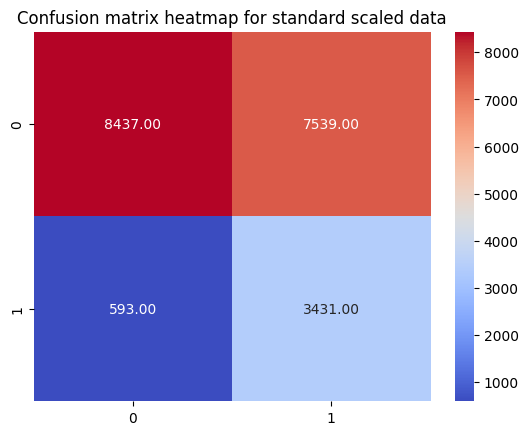

In [76]:
## Confusion matrix for standard scaled features on new data
tn, fp, fn, tp = confusion_matrix(test, predictions_std).ravel()
print('True Negatives', tn, 'False Positives', fp)
print('False Negatives', fn, 'True Positives', tp)
plt.title('Confusion matrix heatmap for standard scaled data')
sns.heatmap(confusion_matrix(test, predictions_std), annot=True, cmap='coolwarm', fmt='.2f')

True Negatives 6168 False Positives 9808
False Negatives 322 True Positives 3702


<Axes: title={'center': 'Confusion matrix heatmap for robust scaled data'}>

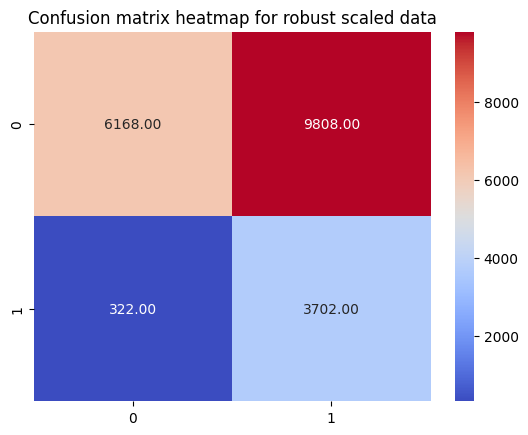

In [77]:
## Confusion matrix for robust scaled features on new data
tn, fp, fn, tp = confusion_matrix(test, predictions_robust).ravel()
print('True Negatives', tn, 'False Positives', fp)
print('False Negatives', fn, 'True Positives', tp)
plt.title('Confusion matrix heatmap for robust scaled data')
sns.heatmap(confusion_matrix(test, predictions_robust), annot=True, cmap='coolwarm', fmt='.2f')

True Negatives 12703 False Positives 3273
False Negatives 1208 True Positives 2816


<Axes: title={'center': 'Confusion matrix heatmap for normal (min-max) scaled data'}>

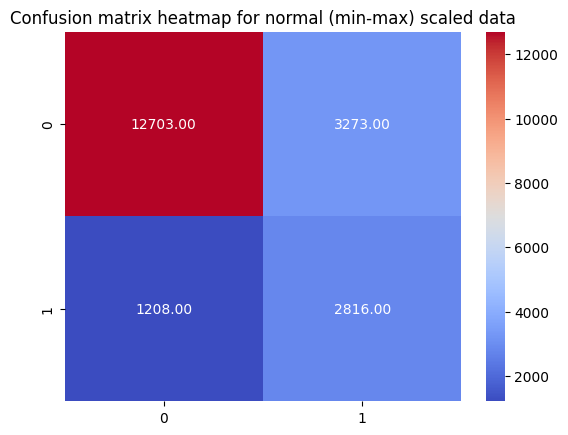

In [78]:
## Confusion matrix for normal (min-max) scaled features on new data
tn, fp, fn, tp = confusion_matrix(test, predictions_minmax).ravel()
print('True Negatives', tn, 'False Positives', fp)
print('False Negatives', fn, 'True Positives', tp)
plt.title('Confusion matrix heatmap for normal (min-max) scaled data')
sns.heatmap(confusion_matrix(test, predictions_minmax), annot=True, cmap='coolwarm', fmt='.2f')